DATA COLLECTION

In [ ]:
# Install required library
!pip install yfinance

import yfinance as yf
import pandas as pd

# Download Gold Futures data
df = yf.download(
    "GC=F",
    start="2000-09-01",
    end="2024-12-31",
    interval="1d"
)

# Save raw dataset
df.to_csv("gold_raw_2000_2024.csv")
print("Dataset Shape:", df.shape)


/tmp/ipython-input-3126806988.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

Dataset Shape: (6103, 5)


In [ ]:
print(df.head())

Price            Close        High         Low        Open Volume
Ticker            GC=F        GC=F        GC=F        GC=F   GC=F
Date                                                             
2000-09-01  277.000000  277.000000  277.000000  277.000000      0
2000-09-05  275.799988  275.799988  275.799988  275.799988      2
2000-09-06  274.200012  274.200012  274.200012  274.200012      0
2000-09-07  274.000000  274.000000  274.000000  274.000000    125
2000-09-08  273.299988  273.299988  273.299988  273.299988      0


In [ ]:
print(df.tail())

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2024-12-23  2612.300049  2627.699951  2611.100098  2620.000000    451
2024-12-24  2620.000000  2620.000000  2609.500000  2613.000000     35
2024-12-26  2638.800049  2638.800049  2627.899902  2628.500000     84
2024-12-27  2617.199951  2617.699951  2616.399902  2617.699951    642
2024-12-30  2606.100098  2626.899902  2597.000000  2620.699951    794


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6103 entries, 2000-09-01 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   6103 non-null   float64
 1   (High, GC=F)    6103 non-null   float64
 2   (Low, GC=F)     6103 non-null   float64
 3   (Open, GC=F)    6103 non-null   float64
 4   (Volume, GC=F)  6103 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 286.1 KB
None


In [ ]:
print(df.describe())

Price         Close         High          Low         Open         Volume
Ticker         GC=F         GC=F         GC=F         GC=F           GC=F
count   6103.000000  6103.000000  6103.000000  6103.000000    6103.000000
mean    1161.078764  1166.894839  1155.121154  1161.140734    4278.728494
std      580.172295   583.280006   576.969550   580.160105   24321.811199
min      255.100006   256.100006   255.000000   255.000000       0.000000
25%      632.000000   633.049988   628.450012   632.799988      21.000000
50%     1233.900024  1240.699951  1228.000000  1233.300049     106.000000
75%     1615.349976  1624.099976  1607.250000  1618.050049     400.000000
max     2788.500000  2789.000000  2774.600098  2787.399902  386334.000000


PREPROCESSING

a) Missing Values

In [ ]:
print("Missing values before:\n", df.isnull().sum())

df = df.ffill()

print("Missing values after:\n", df.isnull().sum())


Missing values before:
 Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64
Missing values after:
 Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64


b) Noise Handling (Rolling Mean Smoothing)

In [ ]:
df['Close_Smoothed'] = df['Close'].rolling(window=7).mean()
df.dropna(inplace=True)


c) Outlier Handling (IQR Method)

In [ ]:
Q1 = df['Close_Smoothed'].quantile(0.25)
Q3 = df['Close_Smoothed'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Close_Smoothed'] >= lower) & (df['Close_Smoothed'] <= upper)]


d) Data Imbalance

In [ ]:
# Time-series regression problem → No class imbalance
print("This is a continuous time-series dataset; data imbalance is not applicable.")


This is a continuous time-series dataset; data imbalance is not applicable.


DATA TRANSFORMATION

a) Feature Selection

In [ ]:
df = df[['Close_Smoothed']]
df.rename(columns={'Close_Smoothed': 'Gold_Price'}, inplace=True)


b) Feature Engineering

In [ ]:
# Lag features
df['Lag_1'] = df['Gold_Price'].shift(1)
df['Lag_7'] = df['Gold_Price'].shift(7)
df['Lag_30'] = df['Gold_Price'].shift(30)

# Rolling statistics
df['Rolling_Mean_7'] = df['Gold_Price'].rolling(7).mean()
df['Rolling_Mean_30'] = df['Gold_Price'].rolling(30).mean()

df.dropna(inplace=True)


c) Encoding (Time-based Encoding)

In [ ]:
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek


d) Normalization / Scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Gold_Price']] = scaler.fit_transform(df[['Gold_Price']])


e) Dimensionality Reduction / Feature Selection

In [ ]:
# Remove redundant features manually
df = df[['Gold_Price', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_7', 'Rolling_Mean_30']]


MODELLING

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train-test split
train = df.iloc[:-365]
test = df.iloc[-365:]

# ===============================
# MODEL 1 : ARIMA
# ===============================
arima_model = ARIMA(train['Gold_Price'], order=(5,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))


# ===============================
# MODEL 2 : SARIMA
# ===============================
sarima_model = SARIMAX(train['Gold_Price'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12))

sarima_fit = sarima_model.fit()
sarima_pred = sarima_fit.forecast(len(test))


# ===============================
# MODEL 3 : RANDOM FOREST
# ===============================

features = df.drop(columns=['Gold_Price'])
target = df['Gold_Price']

X_train = features.iloc[:-365]
X_test = features.iloc[-365:]

y_train = target.iloc[:-365]
y_test = target.iloc[-365:]

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

EVALUATION

In [ ]:
import numpy as np

def evaluate_model(true, pred, model_name):

    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    # Convert 'true' to a numpy array to avoid index type mismatch for MAPE calculation
    mape = np.mean(np.abs((true.values - pred)/true.values))*100

    return [model_name, mae, rmse, mape]


results = []

results.append(evaluate_model(y_test, arima_pred, "ARIMA"))
results.append(evaluate_model(y_test, sarima_pred, "SARIMA"))
results.append(evaluate_model(y_test, rf_pred, "Random Forest"))

results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","MAPE"])

print("\nModel Comparison:")
print(results_df)


Model Comparison:
           Model       MAE      RMSE       MAPE
0          ARIMA  0.116973  0.153485        NaN
1         SARIMA  0.039472  0.047743        NaN
2  Random Forest  0.101030  0.141691  11.224603


/tmp/ipython-input-1754500560.py:7: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((true - pred)/true))*100
/tmp/ipython-input-1754500560.py:7: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  mape = np.mean(np.abs((true - pred)/true))*100


TIME SERIES CROSS VALIDATION

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(rf_model, features, target, cv=tscv)

print("\nRandom Forest Cross Validation Score:", cv_scores.mean())


Random Forest Cross Validation Score: -0.15970612172147058


RESIDUAL ANALYSIS

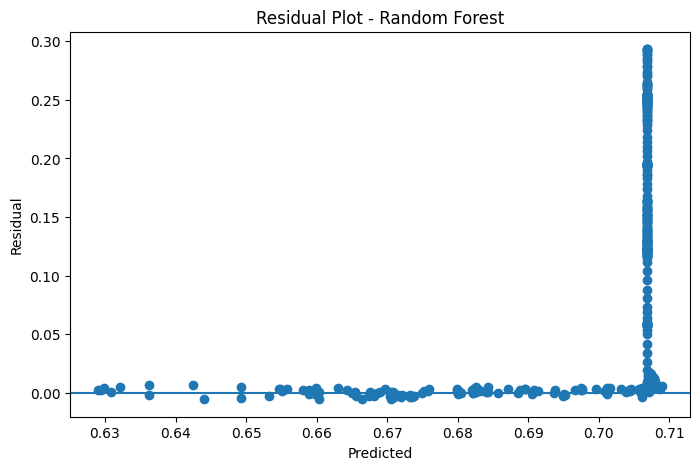

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))
plt.scatter(rf_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

MODEL COMPARISON - VISUALISATION

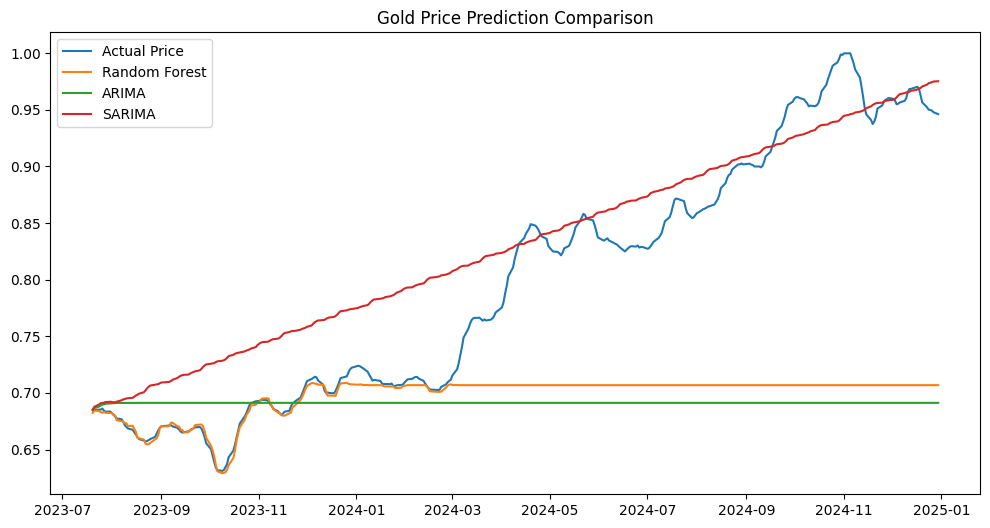

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(test.index, y_test, label="Actual Price")
plt.plot(test.index, rf_pred, label="Random Forest")
plt.plot(test.index, arima_pred, label="ARIMA")
plt.plot(test.index, sarima_pred, label="SARIMA")

plt.legend()
plt.title("Gold Price Prediction Comparison")
plt.show()

SAVE & DOWNLOAD CLEANED DATASET

In [ ]:
df.to_csv("gold_cleaned_feature_engineered_final.csv")

from google.colab import files
files.download("gold_cleaned_feature_engineered_final.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>